# 1. Análise Exploratória de Dados (EDA)



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm

# Configurações visuais para os gráficos
%matplotlib inline
sns.set_theme(style="whitegrid")

# Carregamento dos dados (Usando a Opção 2 que funcionou para você)
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

print(f"Dataset de Treino: {df_train.shape[0]} linhas e {df_train.shape[1]} colunas.")
print(f"Dataset de Teste: {df_test.shape[0]} linhas e {df_test.shape[1]} colunas.")

Dataset de Treino: 1460 linhas e 81 colunas.
Dataset de Teste: 1459 linhas e 80 colunas.


### 1.1 Análise Estatística e Distribuição da Variável Alvo (`SalePrice`)
* **Objetivo:** Compreender o comportamento do preço de venda das casas, analisando suas estatísticas descritivas e o formato de sua curva de distribuição.


Estatísticas Descritivas de SalePrice:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


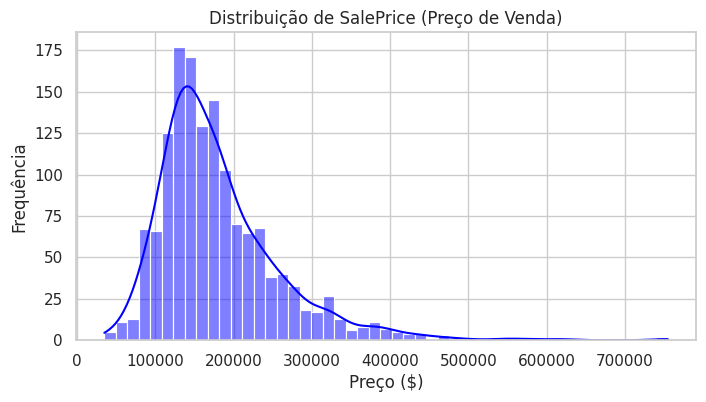

Assimetria (Skewness): 1.88
Curtose (Kurtosis): 6.54


In [ ]:
# Análise Estatística Descritiva
print("Estatísticas Descritivas de SalePrice:")
print(df_train['SalePrice'].describe())

# Gráfico de Distribuição
plt.figure(figsize=(8, 4))
sns.histplot(df_train['SalePrice'], kde=True, color='blue')
plt.title('Distribuição de SalePrice (Preço de Venda)')
plt.xlabel('Preço ($)')
plt.ylabel('Frequência')
plt.show()

# Análise de Assimetria (Skewness) e Curtose (Kurtosis)
print(f"Assimetria (Skewness): {df_train['SalePrice'].skew():.2f}")
print(f"Curtose (Kurtosis): {df_train['SalePrice'].kurt():.2f}")



### 1.2 Matriz de Correlação de Pearson (Variáveis Numéricas)
* **Objetivo:** Identificar o grau de associação linear entre as variáveis numéricas do dataset e o preço final do imóvel.

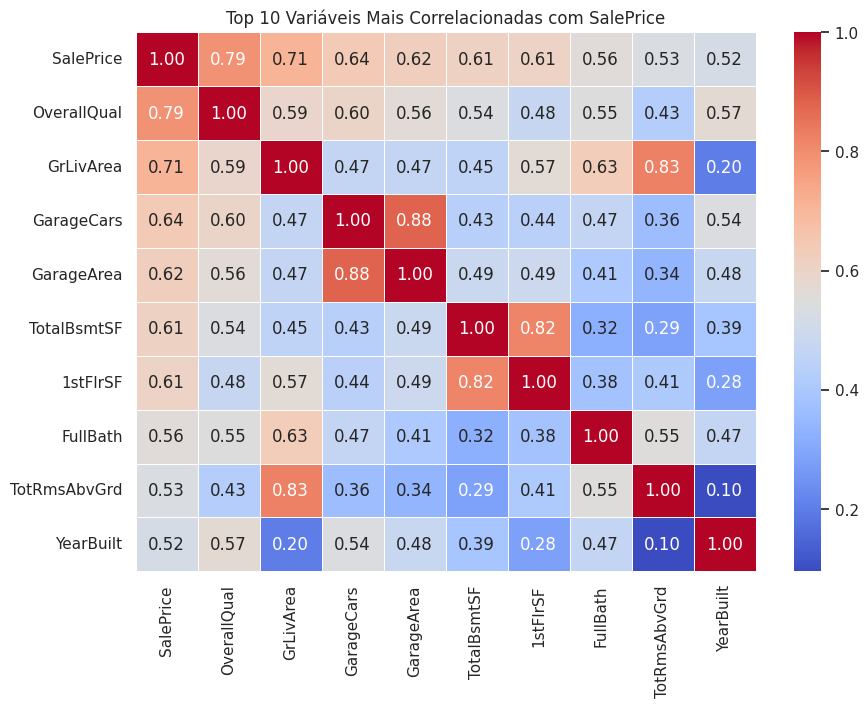

In [ ]:
# Selecionando apenas colunas numéricas para a matriz
numeric_features = df_train.select_dtypes(include=[np.number])
corr_matrix = numeric_features.corr()

# Top 10 variáveis mais correlacionadas com SalePrice
top_corr_features = corr_matrix['SalePrice'].sort_values(ascending=False).index[:10]

# Construção do Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(df_train[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Top 10 Variáveis Mais Correlacionadas com SalePrice')
plt.show()

### 1.3 Análise de Relações Lineares e Identificação de Outliers
* **Objetivo:** Avaliar de forma gráfica as variáveis mais promissoras mapeadas na matriz de correlação contra a variável `SalePrice` para detectar discrepâncias.

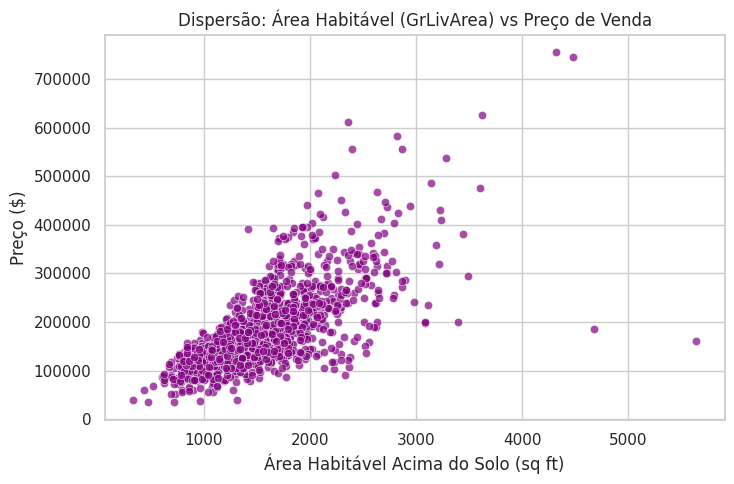

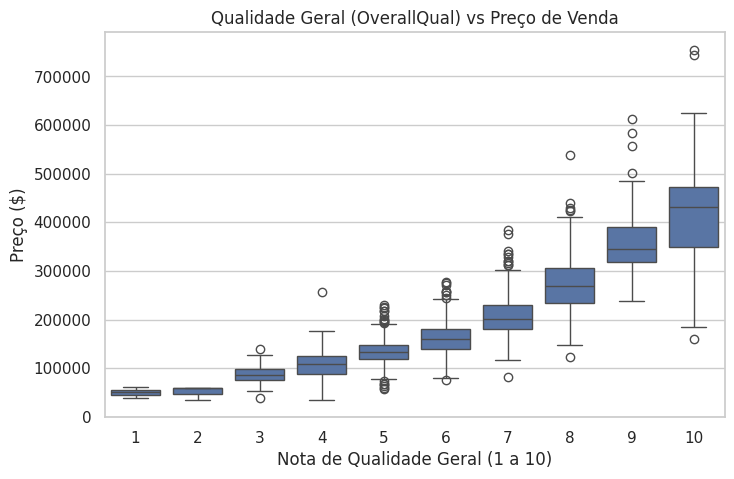

In [ ]:
# Relação Gráfica: Área Habitável (GrLivArea) vs Preço
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df_train['GrLivArea'], y=df_train['SalePrice'], color='purple', alpha=0.7)
plt.title('Dispersão: Área Habitável (GrLivArea) vs Preço de Venda')
plt.xlabel('Área Habitável Acima do Solo (sq ft)')
plt.ylabel('Preço ($)')
plt.show()

# Relação Gráfica: Qualidade Geral (OverallQual) vs Preço
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_train['OverallQual'], y=df_train['SalePrice'])
plt.title('Qualidade Geral (OverallQual) vs Preço de Venda')
plt.xlabel('Nota de Qualidade Geral (1 a 10)')
plt.ylabel('Preço ($)')
plt.show()

**Observação:** A distribuição tem assimetria positiva (cauda longa à direita). Normalmente, em modelos de regressão linear, pode ser útil aplicar uma transformação logarítmica em variáveis assimétricas na fase de Feature Engineering.

### 1.4 Análise Descritiva de Variáveis Categóricas Importantes
* **Objetivo:** Entender o impacto que os atributos qualitativos (textos/categorias) exercem sobre a variação e a dispersão dos preços dos imóveis.

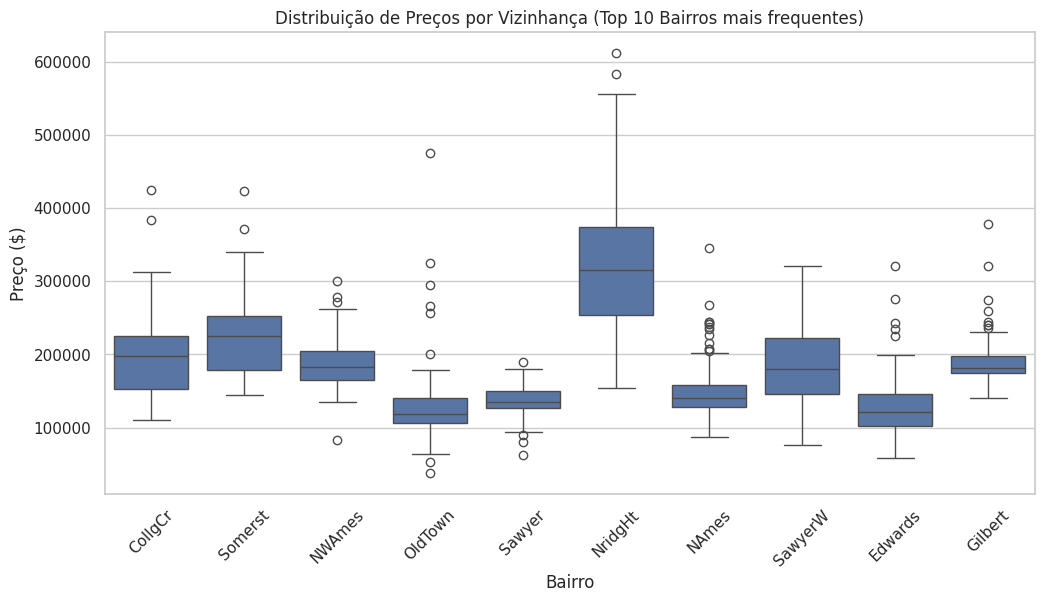

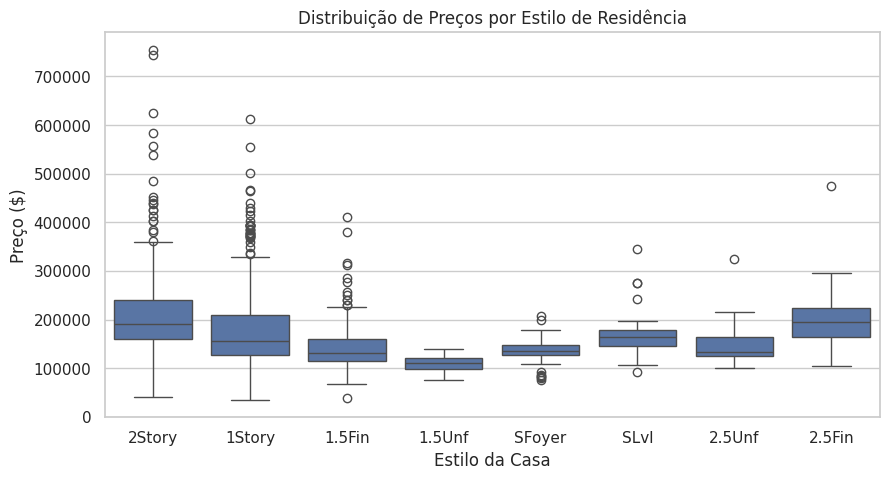

In [ ]:
# Análise por Vizinhança (Neighborhood) - Selecionando as 10 mais frequentes para o gráfico ficar limpo
top_neighborhoods = df_train['Neighborhood'].value_counts().index[:10]
df_top_neighborhoods = df_train[df_train['Neighborhood'].isin(top_neighborhoods)]

plt.figure(figsize=(12, 6))
sns.boxplot(x='Neighborhood', y='SalePrice', data=df_top_neighborhoods)
plt.title('Distribuição de Preços por Vizinhança (Top 10 Bairros mais frequentes)')
plt.xticks(rotation=45)
plt.xlabel('Bairro')
plt.ylabel('Preço ($)')
plt.show()

# Análise por Estilo de Construção (HouseStyle)
plt.figure(figsize=(10, 5))
sns.boxplot(x='HouseStyle', y='SalePrice', data=df_train)
plt.title('Distribuição de Preços por Estilo de Residência')
plt.xlabel('Estilo da Casa')
plt.ylabel('Preço ($)')
plt.show()

# 2. Feature Engineering (Engenharia de Características)

Neste tópico, focaremos exclusivamente na Engenharia de Características (Feature Engineering) para selecionar e transformar as variáveis do conjunto de dados de preços de casas nos EUA, preparando os dados para a modelagem preditiva.

### 2.1 Tratamento Inicial de Valores Ausentes (Dataset de Treino)
Nesta etapa, aplicamos o mapeamento do dicionário de dados (`data_description.txt`) para tratar a grande massa de valores nulos no conjunto de treino, diferenciando os casos onde a ausência de dados indica a não existência do recurso daqueles que indicam valor zero ou omissão.

In [9]:
# Carregando o dataset de treino
df_train = pd.read_csv('train.csv')

# Tratamento de nulos conforme data_description.txt
cols_na_is_none = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
                   'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                   'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
                   'MasVnrType']

for col in cols_na_is_none:
    if col in df_train.columns:
        df_train[col] = df_train[col].fillna('None')

cols_na_is_zero = ['GarageYrBlt', 'GarageArea', 'GarageCars',
                   'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF','TotalBsmtSF',
                   'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']

for col in cols_na_is_zero:
    if col in df_train.columns:
        df_train[col] = df_train[col].fillna(0)

# Preenchimento da LotFrontage com a mediana do bairro
df_train['LotFrontage'] = df_train.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

# Preenchimento com a moda para demais categóricas residuais
df_train['Electrical'] = df_train['Electrical'].fillna(df_train['Electrical'].mode()[0])

print(f"Dados originais carregados e limpos preliminarmente com formato: {df_train.shape}")

Dados originais carregados e limpos preliminarmente com formato: (1460, 81)


### 2.2 Tratamento Residual e Validação
Preenchimento de valores nulos residuais não mapeados nas listas anteriores por meio de métricas gerais (mediana para numéricos e moda para categóricos) e verificação final da integridade do dataset.

In [12]:
# Preenchimento residual automático para colunas numéricas e categóricas
num_cols = df_train.select_dtypes(include=['number']).columns
cat_cols = df_train.select_dtypes(include=['object']).columns

for col in num_cols:
    df_train[col] = df_train[col].fillna(df_train[col].median())

for col in cat_cols:
    df_train[col] = df_train[col].fillna(df_train[col].mode()[0])

# Verificação final de consistência
print(f"Valores nulos residuais após a limpeza: {df_train.isnull().sum().sum()}")

Valores nulos residuais após a limpeza: 0


# 3. Aprendizagem supervisionada (Regressão Linear)

### 3.1 Criação da Regressão Linear

Nesta etapa, preparamos os dados convertendo as variáveis categóricas em numéricas via One-Hot Encoding, separamos os dados entre preditores (X) e variável alvo (y), e realizamos o treinamento e a avaliação do modelo de Regressão Linear.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Isolando a variável alvo e aplicando One-Hot Encoding nos preditores
# Nota: Usamos df_train que foi limpo na etapa anterior
y = np.log1p(df_train['SalePrice'])
X = df_train.drop(columns=['Id', 'SalePrice'])

# Transformando variáveis qualitativas em binárias (0 ou 1)
X_encoded = pd.get_dummies(X, drop_first=True)

# 2. Divisão dos dados em treino (80%) e validação interna (20%)
X_train, X_val, y_train, y_val = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 3. Inicialização e Treinamento do Modelo
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Predição no conjunto de validação
y_pred_log = model.predict(X_val)

# Como o modelo previu o LOG do preço, revertemos para a escala original em Dólares
y_val_actual = np.expm1(y_val)
y_pred_actual = np.expm1(y_pred_log)

# 5. Cálculo das Métricas de Avaliação
mae = mean_absolute_error(y_val_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_val_actual, y_pred_actual))
r2 = r2_score(y_val_actual, y_pred_actual)

# Exibição direta dos resultados
print("MÉTRICAS DE DESEMPENHO DO MODELO:")
print(f"MAE  (Mean Absolute Error):   ${mae:.2f}")
print(f"RMSE (Root Mean Squared Error): ${rmse:.2f}")
print(f"R² Score (Ajuste do Modelo):   {r2:.4f}")

MÉTRICAS DE DESEMPENHO DO MODELO:
MAE  (Mean Absolute Error):   $15546.95
RMSE (Root Mean Squared Error): $25466.34
R² Score (Ajuste do Modelo):   0.9154


### 3.2 Análise Gráfica dos Resultados
Gráfico de dispersão cruzando os valores reais contra os valores preditos pelo modelo para avaliar visualmente a qualidade do ajuste linear.

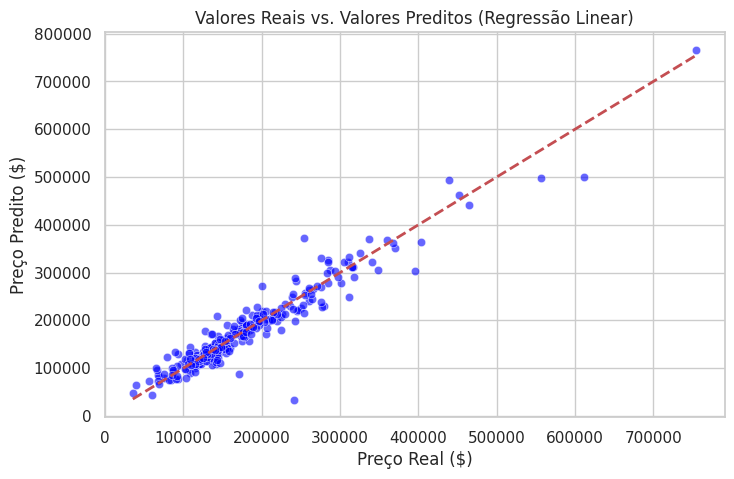

In [14]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_val_actual, y=y_pred_actual, alpha=0.6, color='blue')
plt.plot([y_val_actual.min(), y_val_actual.max()], [y_val_actual.min(), y_val_actual.max()], 'r--', lw=2)
plt.title('Valores Reais vs. Valores Preditos (Regressão Linear)')
plt.xlabel('Preço Real ($)')
plt.ylabel('Preço Predito ($)')
plt.show()

# 4. Aprendizagem supervisionada (Classificação Binária)

Nesta etapa, a variável `SalePrice` é transformada em uma variável binária para responder a uma nova pergunta de negócio: **a casa pertence ao grupo de preço alto ou preço baixo?**

Para isso, usamos a mediana do preço de venda como limite de separação:

- `0` → preço baixo ou igual à mediana;
- `1` → preço alto, acima da mediana.

Em seguida, treinamos e comparamos modelos de classificação usando métricas adequadas para problemas supervisionados de classificação.

### 4.1 Criação da variável alvo binária

A mediana foi escolhida como ponto de corte por dividir o conjunto de dados de forma equilibrada, evitando uma classe muito maior que a outra.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Criação da variável binária de classificação
limiar_preco = df_train['SalePrice'].median()
y_class = (df_train['SalePrice'] > limiar_preco).astype(int)

print(f"Limiar usado para definir preço alto/baixo: ${limiar_preco:,.2f}")
print("Distribuição das classes:")
print(y_class.value_counts().rename(index={0: 'Preço baixo', 1: 'Preço alto'}))

# Reutilizamos as variáveis preditoras já codificadas na etapa de regressão
X_class = X_encoded.copy()

X_train_cls, X_val_cls, y_train_cls, y_val_cls = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

print(f"Treino: {X_train_cls.shape[0]} registros")
print(f"Validação: {X_val_cls.shape[0]} registros")

### 4.2 Treinamento e comparação dos modelos de classificação

Foram testados três modelos supervisionados:

- **Regressão Logística:** modelo linear simples e interpretável;
- **Árvore de Decisão:** modelo baseado em regras de decisão;
- **Random Forest:** conjunto de várias árvores de decisão, geralmente mais robusto.

As métricas usadas foram `accuracy`, `precision`, `recall` e `F1-score`.

In [ ]:
modelos_classificacao = {
    'Regressão Logística': Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=3000, random_state=42))
    ]),
    'Árvore de Decisão': DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
}

resultados_classificacao = []
modelos_classificacao_treinados = {}
predicoes_classificacao = {}

for nome, modelo_cls in modelos_classificacao.items():
    modelo_cls.fit(X_train_cls, y_train_cls)
    y_pred_cls = modelo_cls.predict(X_val_cls)

    modelos_classificacao_treinados[nome] = modelo_cls
    predicoes_classificacao[nome] = y_pred_cls

    resultados_classificacao.append({
        'Modelo': nome,
        'Accuracy': accuracy_score(y_val_cls, y_pred_cls),
        'Precision': precision_score(y_val_cls, y_pred_cls),
        'Recall': recall_score(y_val_cls, y_pred_cls),
        'F1-score': f1_score(y_val_cls, y_pred_cls)
    })

class_results_df = pd.DataFrame(resultados_classificacao).sort_values(by='F1-score', ascending=False)

print("Comparação dos modelos de classificação:")
display(class_results_df.round(4))

### 4.3 Matriz de confusão e relatório do melhor modelo

A matriz de confusão mostra quantas casas foram classificadas corretamente ou incorretamente como preço alto/baixo. O melhor modelo foi selecionado pelo maior `F1-score`, pois essa métrica equilibra precisão e recall.

In [ ]:
melhor_modelo_cls_nome = class_results_df.iloc[0]['Modelo']
melhor_pred_cls = predicoes_classificacao[melhor_modelo_cls_nome]

print(f"Melhor modelo de classificação: {melhor_modelo_cls_nome}\n")
print(classification_report(
    y_val_cls,
    melhor_pred_cls,
    target_names=['Preço baixo', 'Preço alto']
))

cm = confusion_matrix(y_val_cls, melhor_pred_cls)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Previsto: baixo', 'Previsto: alto'],
    yticklabels=['Real: baixo', 'Real: alto']
)
plt.title(f'Matriz de Confusão - {melhor_modelo_cls_nome}')
plt.xlabel('Classe prevista')
plt.ylabel('Classe real')
plt.show()

# 5. Aprendizagem não supervisionada

Nesta etapa, aplicamos técnicas não supervisionadas para encontrar padrões sem usar diretamente a variável-alvo `SalePrice` como resposta do modelo.

Foram usadas três abordagens:

- **KMeans:** clusterização para agrupar imóveis com características semelhantes;
- **PCA:** redução de dimensionalidade para visualizar os dados em duas dimensões;
- **Local Outlier Factor (LOF):** identificação de observações com comportamento anômalo.

### 5.1 Preparação dos dados para modelos não supervisionados

Como os algoritmos não supervisionados são sensíveis à escala das variáveis, os dados codificados foram padronizados com `StandardScaler`.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import silhouette_score

# Dados preditores codificados e padronizados
X_unsup = X_encoded.copy()

scaler_unsup = StandardScaler()
X_unsup_scaled = scaler_unsup.fit_transform(X_unsup)

print(f"Base usada no aprendizado não supervisionado: {X_unsup_scaled.shape[0]} registros e {X_unsup_scaled.shape[1]} variáveis após codificação.")

### 5.2 Clusterização com KMeans

O KMeans foi aplicado com diferentes valores de `k`. Para escolher uma quantidade adequada de grupos, usamos o **Silhouette Score**, em que valores maiores indicam grupos mais bem separados.

In [ ]:
silhouette_resultados = []

for k in range(2, 7):
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_unsup_scaled)
    silhouette_resultados.append({
        'k': k,
        'Silhouette Score': silhouette_score(X_unsup_scaled, labels_temp)
    })

silhouette_df = pd.DataFrame(silhouette_resultados)
melhor_k = int(silhouette_df.loc[silhouette_df['Silhouette Score'].idxmax(), 'k'])

print("Resultados de Silhouette Score por quantidade de clusters:")
display(silhouette_df.round(4))
print(f"Melhor valor de k encontrado: {melhor_k}")

plt.figure(figsize=(7, 4))
sns.lineplot(data=silhouette_df, x='k', y='Silhouette Score', marker='o')
plt.title('Silhouette Score por número de clusters')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score')
plt.show()

# Treinamento final do KMeans com o melhor k
kmeans = KMeans(n_clusters=melhor_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_unsup_scaled)

print("Quantidade de imóveis por cluster:")
print(pd.Series(clusters).value_counts().sort_index())

### 5.3 Redução de dimensionalidade com PCA

O PCA reduz o conjunto de variáveis para dois componentes principais, permitindo visualizar os clusters em um gráfico bidimensional.

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_unsup_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = clusters
pca_df['SalePrice'] = df_train['SalePrice'].values

variancia_pca = pca.explained_variance_ratio_
print(f"Variância explicada pelo PC1: {variancia_pca[0]:.2%}")
print(f"Variância explicada pelo PC2: {variancia_pca[1]:.2%}")
print(f"Variância explicada acumulada: {variancia_pca.sum():.2%}")

plt.figure(figsize=(8, 5))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='tab10', alpha=0.75)
plt.title('Visualização dos clusters com PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Cluster')
plt.show()

### 5.4 Interpretação dos clusters

Para interpretar os grupos encontrados, analisamos estatísticas de preço, área, qualidade geral e outras características relevantes por cluster.

In [ ]:
df_clusters = df_train.copy()
df_clusters['Cluster'] = clusters

variaveis_resumo_cluster = [
    'SalePrice',
    'GrLivArea',
    'OverallQual',
    'YearBuilt',
    'TotalBsmtSF',
    'GarageCars'
]

cluster_summary = df_clusters.groupby('Cluster')[variaveis_resumo_cluster].agg(['count', 'mean', 'median']).round(2)

print("Resumo dos clusters:")
display(cluster_summary)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clusters, x='Cluster', y='SalePrice')
plt.title('Distribuição de preços por cluster')
plt.xlabel('Cluster')
plt.ylabel('Preço de venda ($)')
plt.show()

### 5.5 Análise de outliers com Local Outlier Factor (LOF)

O Local Outlier Factor identifica observações que destoam de sua vizinhança. No contexto do dataset, esses pontos podem representar imóveis com combinações incomuns de preço, área, qualidade, localização ou demais atributos.

In [ ]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_labels = lof.fit_predict(X_unsup_scaled)

pca_df['LOF'] = np.where(lof_labels == -1, 'Outlier', 'Normal')
df_clusters['LOF'] = pca_df['LOF'].values

print("Quantidade de registros classificados pelo LOF:")
print(pca_df['LOF'].value_counts())

lof_summary = df_clusters.groupby('LOF')[['SalePrice', 'GrLivArea', 'OverallQual', 'TotalBsmtSF']].agg(['count', 'mean', 'median']).round(2)
print("Resumo comparando imóveis normais e outliers:")
display(lof_summary)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='LOF', style='LOF', alpha=0.75)
plt.title('Identificação de outliers com LOF no espaço PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Classificação LOF')
plt.show()

# 6. Métricas de avaliação, comparação e conclusão

Este tópico consolida os resultados dos modelos supervisionados e não supervisionados. A comparação final permite observar:

- qual modelo de regressão teve melhor desempenho na previsão de preço;
- qual modelo de classificação separou melhor imóveis de preço alto e baixo;
- quais padrões foram encontrados pelas técnicas não supervisionadas.

### 6.1 Comparação complementar de modelos de regressão

Além da Regressão Linear já treinada anteriormente, foram avaliados modelos baseados em árvore para comparação de desempenho na tarefa de regressão.

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

modelos_regressao = {
    'Regressão Linear': LinearRegression(),
    'Árvore de Decisão': DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1)
}

resultados_regressao = []

for nome, modelo_reg in modelos_regressao.items():
    modelo_reg.fit(X_train, y_train)
    y_pred_log_modelo = modelo_reg.predict(X_val)

    y_pred_modelo = np.expm1(y_pred_log_modelo)
    y_real_modelo = np.expm1(y_val)

    resultados_regressao.append({
        'Modelo': nome,
        'MAE': mean_absolute_error(y_real_modelo, y_pred_modelo),
        'RMSE': np.sqrt(mean_squared_error(y_real_modelo, y_pred_modelo)),
        'R²': r2_score(y_real_modelo, y_pred_modelo)
    })

regression_results_df = pd.DataFrame(resultados_regressao).sort_values(by='RMSE')

print("Comparação dos modelos de regressão:")
display(regression_results_df.round(4))

plt.figure(figsize=(8, 5))
sns.barplot(data=regression_results_df, x='Modelo', y='RMSE')
plt.title('Comparação de RMSE entre modelos de regressão')
plt.xlabel('Modelo')
plt.ylabel('RMSE')
plt.xticks(rotation=15)
plt.show()

### 6.2 Consolidação dos resultados de classificação e aprendizado não supervisionado

A tabela abaixo organiza os principais resultados obtidos nas etapas de classificação, clusterização, redução de dimensionalidade e análise de outliers.

In [ ]:
melhor_regressao = regression_results_df.iloc[0]
melhor_classificacao = class_results_df.iloc[0]
qtd_outliers = int((pca_df['LOF'] == 'Outlier').sum())
qtd_normais = int((pca_df['LOF'] == 'Normal').sum())

resumo_final = pd.DataFrame([
    {
        'Etapa': 'Regressão',
        'Técnica/Modelo': melhor_regressao['Modelo'],
        'Resultado principal': f"RMSE = {melhor_regressao['RMSE']:.2f}; R² = {melhor_regressao['R²']:.4f}",
        'Interpretação': 'Modelo usado para prever diretamente o preço de venda dos imóveis.'
    },
    {
        'Etapa': 'Classificação',
        'Técnica/Modelo': melhor_classificacao['Modelo'],
        'Resultado principal': f"F1-score = {melhor_classificacao['F1-score']:.4f}; Accuracy = {melhor_classificacao['Accuracy']:.4f}",
        'Interpretação': 'Modelo usado para separar imóveis em preço alto e preço baixo.'
    },
    {
        'Etapa': 'Clusterização',
        'Técnica/Modelo': 'KMeans',
        'Resultado principal': f"Melhor k = {melhor_k}",
        'Interpretação': 'Agrupou imóveis com características semelhantes sem usar a variável-alvo como resposta.'
    },
    {
        'Etapa': 'Redução de dimensionalidade',
        'Técnica/Modelo': 'PCA',
        'Resultado principal': f"Variância explicada em 2 componentes = {variancia_pca.sum():.2%}",
        'Interpretação': 'Permitiu visualizar a estrutura dos dados e os clusters em duas dimensões.'
    },
    {
        'Etapa': 'Análise de outliers',
        'Técnica/Modelo': 'Local Outlier Factor',
        'Resultado principal': f"{qtd_outliers} outliers e {qtd_normais} registros normais",
        'Interpretação': 'Identificou imóveis com combinações de características incomuns em relação ao restante da base.'
    }
])

print("Resumo final das técnicas aplicadas:")
display(resumo_final)

### 6.3 Conclusão geral

A análise mostrou que o preço de venda dos imóveis é fortemente influenciado por variáveis relacionadas à qualidade geral da construção, área habitável, presença de garagem, tamanho do porão e localização. A transformação logarítmica da variável `SalePrice` ajudou a reduzir a assimetria da distribuição e favoreceu o desempenho dos modelos de regressão.

Na etapa supervisionada, os modelos de regressão permitiram prever o preço de venda, enquanto os modelos de classificação possibilitaram separar imóveis em faixas de preço alto e baixo. Já na etapa não supervisionada, o KMeans encontrou grupos de imóveis semelhantes, o PCA auxiliou na visualização da estrutura dos dados e o LOF destacou possíveis imóveis atípicos.

Com isso, o projeto reúne as principais etapas de um fluxo de análise de dados e aprendizagem de máquina: exploração inicial, tratamento de dados, engenharia de características, modelagem supervisionada, modelagem não supervisionada, avaliação por métricas e interpretação dos resultados.